In [17]:
using CairoMakie, LaTeXStrings, Revise
using LinearAlgebra, StatsBase
using JLD2
includet("Utils.jl")
using .Utils
includet("FigureStyles.jl")
using .FigureStyles
includet("DMFT.jl")
using .DMFT

In [27]:
# Run TheoreticalPRDchn.jl
data = load("results/TheoreticalPRDchn.jld2");
result_chn = data["result_chn"]
τchn_vec = data["τ_chn_vec"]
g_eff_vec = data["g_eff_vec"]
dt = data["dt"]
N = data["N"]
cutoff = 12.0
Dϕ_PR = zeros(length(g_eff_vec), length(τchn_vec))
C2 = zeros(length(g_eff_vec), length(τchn_vec))
C4 = zeros(length(g_eff_vec), length(τchn_vec))
for (i, g_eff) in enumerate(g_eff_vec)
    for (j, τchn) in enumerate(τchn_vec)
        τ = (τchn, 0.0)
        g = compute_g(g_eff, τ)
        χϕ = result_chn[i, j].χϕ
        cut_off = round(Int, cutoff/dt)
        χϕ[cut_off:end] .= 0.0 # Remove noisy tail
        Dϕ_PR[i, j], C2[i, j], C4[i, j] = TheoreticalPRϕ(N, g, τ, result_chn[i, j].Cϕ, χϕ, dt)
    end
end

theo_result_chn = (
    τ = collect(τchn_vec),
    Dϕ = Dϕ_PR,
    C2 = C2,
    C4 = C4);

In [28]:
# Run TheoreticalPRDrec.jl
data = load("results/TheoreticalPRDrec.jld2");
result_rec = data["result_rec"]
τrec_vec = data["τ_rec_vec"]
g_eff_vec = data["g_eff_vec"]
dt_vec = data["dt_vec"]
N = data["N"]
cutoff = [2.6, 5.0, 10.0, 20.0, 20.0, 50.0, 50.0, 100.0, 100.0, 200.0]
Dϕ_PR = zeros(length(g_eff_vec), length(τrec_vec))
C2 = zeros(length(g_eff_vec), length(τrec_vec))
C4 = zeros(length(g_eff_vec), length(τrec_vec))
for (i, g_eff) in enumerate(g_eff_vec)
    for (j, τrec) in enumerate(τrec_vec)
        τ = (0.0, τrec)
        g = compute_g(g_eff, τ)
        dt = dt_vec[j]
        χϕ = result_rec[i, j].χϕ
        cut_off = round(Int, cutoff[j]/dt)
        χϕ[cut_off:end] .= 0.0 # Remove noisy tail
        Dϕ_PR[i, j], C2[i, j], C4[i, j] = TheoreticalPRϕ(N, g, τ, result_rec[i, j].Cϕ, χϕ, dt_vec[j])
    end
end

theo_result_rec = (
    τ = collect(τrec_vec),
    Dϕ = Dϕ_PR,
    C2 = C2,
    C4 = C4);

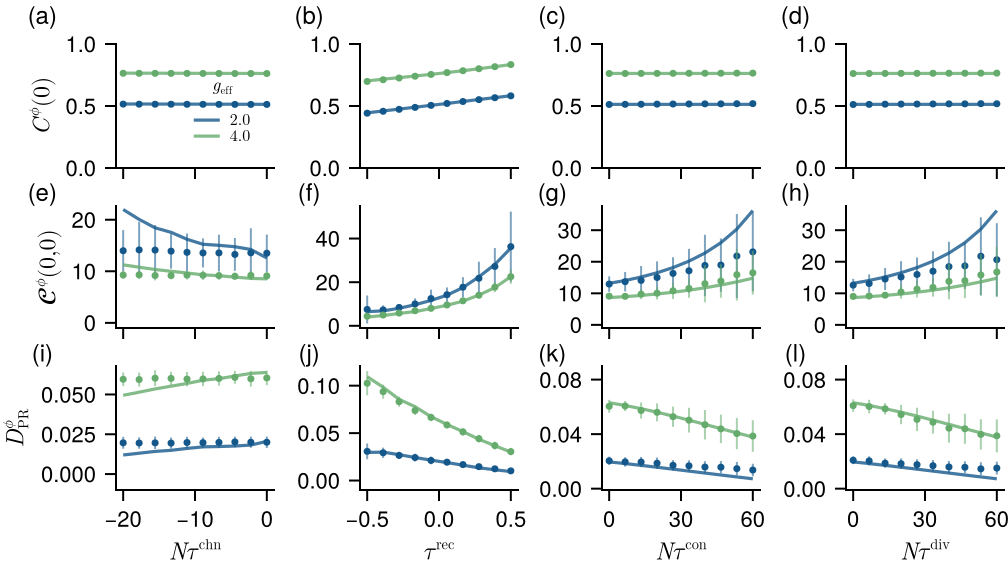

CairoMakie.Screen{IMAGE}


In [29]:
# Run THeoreticalPRDcondiv.jl
theoretical_condiv = load("results/TheoreticalPRDcondiv.jld2")
theo_result_con = theoretical_condiv["result_con"]
theo_result_div = theoretical_condiv["result_div"];

# Run SimulatedPRDimension.jl
data = load("results/NumericalPRDAllMotifs_smallcondiv.jld2")
g_eff_vec = data["g_eff_vec"]
result_chn = data["result_chn"]
result_rec = data["result_rec"]
result_con = data["result_con"]
result_div = data["result_div"]

set_theme!(DoubleColumnTheme)
linewidth = 1.6
errorbar_width = 1.0
markersize = 5
f = Figure(size=(7*72, 3.9*72), figure_padding=(2,2,0.0,0.5))
cmap = to_colormap(:navia10)
g_colors = cmap[[3, 7]]

results = [result_chn, result_rec, result_con, result_div]
theo_results = [theo_result_chn, theo_result_rec, theo_result_con, theo_result_div]
xlabels = [L"N\tau^{\text{chn}}", L"\tau^{\text{rec}}", L"N\tau^{\text{con}}", L"N\tau^{\text{div}}"]
axes_c2  = Vector{Axis}(undef, 4)
axes_c4  = Vector{Axis}(undef, 4)
axes_dpr = Vector{Axis}(undef, 4)

for (col, (res, xlabel)) in enumerate(zip(results, xlabels))

    ax_c2 = Axis(f[1, col],
        limits=(nothing, nothing, 0.0, 1.0)
    )
    axes_c2[col] = ax_c2
    hidexdecorations!(ax_c2, ticks=false)

    if col == 1
        ax_c2.ylabel = L"C^{\phi}(0)"
    end
    if col == 2
        tau = res.τ
        theo_tau = theo_results[col].τ
    else
        tau = N .* res.τ
        theo_tau = N .* theo_results[col].τ
    end
    for (i, g) in enumerate(g_eff_vec)
        theo_C2 = theo_results[col].C2[i, :]
        if col == 1
            lines!(ax_c2, theo_tau, theo_C2; linewidth=linewidth, color=(g_colors[i]), alpha=0.8, label=L"%$(g)")
        else
            lines!(ax_c2, theo_tau, theo_C2; linewidth=linewidth, color=(g_colors[i]), alpha=0.8)
        end
        y_mean = res.C2_mean[i, :]
        y_std  = res.C2_std[i, :]
        errorbars!(ax_c2, tau, y_mean, y_std, y_std;
            color=(g_colors[i], 0.55), linewidth=errorbar_width)
        scatter!(ax_c2, tau, y_mean;
            color=g_colors[i],
            markersize=markersize)
    end

    ax_c4 = Axis(f[2, col],
        limits=(nothing, nothing, -1, nothing)
    )
    axes_c4[col] = ax_c4
    hidexdecorations!(ax_c4, ticks=false)

    if col == 1
        ax_c4.ylabel = L"\mathcal{C}^{\phi}(0,0)"
        ax_c4.yticks = [0, 10, 20]
    end

    for (i, g) in enumerate(g_eff_vec)
        theo_C4 = theo_results[col].C4[i, :]
        lines!(ax_c4, theo_tau, theo_C4; linewidth=linewidth, color=(g_colors[i]), alpha=0.8)
        y_mean = res.C4_mean[i, :]
        y_std  = res.C4_std[i, :]
        errorbars!(ax_c4, tau, y_mean, y_std, y_std;
            color=(g_colors[i], 0.55), linewidth=errorbar_width)
        scatter!(ax_c4, tau, y_mean;
            color=g_colors[i],
            markersize=markersize)
    end

    ax_dpr = Axis(f[3, col],
        xlabel=xlabel,
        limits = (nothing, nothing, -0.01, nothing)
    )
    axes_dpr[col] = ax_dpr

    if col == 1
        ax_dpr.ylabel = L"D^{\phi}_{\text{PR}}"
        ax_c2.xticks = [-20, -10, 0]
        ax_c4.xticks = [-20, -10, 0]
        ax_dpr.xticks = [-20, -10, 0]
    elseif col == 2
        ax_c2.xticks = [-0.5, 0.0, 0.5]
        ax_c4.xticks = [-0.5, 0.0, 0.5]
        ax_dpr.xticks = [-0.5, 0.0, 0.5]
    end

    if col ≥ 3
        ax_dpr.limits = (nothing, nothing, -0.001, 0.09)
        ax_c2.xticks = [0, 30, 60]
        ax_c4.xticks = [0, 30, 60]
        ax_dpr.xticks = [0, 30, 60]
        ax_dpr.yticks = [0.0, 0.04, 0.08]
    end

    for (i, g) in enumerate(g_eff_vec)

        theo_Dϕ = theo_results[col].Dϕ[i, :]
        lines!(ax_dpr, theo_tau, theo_Dϕ; linewidth=linewidth, color=(g_colors[i]), alpha=0.8)

        y_mean = res.Dϕ_mean[i, :]
        y_std  = res.Dϕ_std[i, :]

        errorbars!(ax_dpr, tau, y_mean, y_std, y_std;
            color=(g_colors[i], 0.55), linewidth=errorbar_width)
        scatter!(ax_dpr, tau, y_mean;
            color=g_colors[i],
            markersize=markersize)
    end
end

linkyaxes!(axes_c2[[1, 2]]...)
linkyaxes!(axes_c2[[3, 4]]...)
linkyaxes!(axes_c4[[3, 4]]...)
linkyaxes!(axes_dpr[[3, 4]]...)

panel_labels = ["(a)" "(b)" "(c)" "(d)";
                "(e)" "(f)" "(g)" "(h)";
                "(i)" "(j)" "(k)" "(l)"]
for row in 1:3, col in 1:4
    if row == 1
        Label(f[row, col, TopLeft()], panel_labels[row, col];
            fontsize=12,
            padding=(0f0, 18f0, 8f0, 0f0),
        )
    else
        Label(f[row, col, TopLeft()], panel_labels[row, col];
            fontsize=12, padding=(0f0, 18f0, 0f0, 0f0),
        )
    end
end

axislegend(axes_c2[1], L"g_{\text{eff}}";
    tellwidth=false,
    tellheight=false,
    halign=:right,
    valign=:bottom,
    patchsize=(13, 5),
    rowgap=0.0,
    titlesize=9
)

colgap!(f.layout, 10)
rowgap!(f.layout, 0)

# save("images/PRDAllMotifs.pdf", f, pt_per_unit=1)
display(f)

# Larger parameter range

In [3]:
data = load("results/NumericalPRDAllMotifs.jld2")
N = data["N"]
g_eff_vec = data["g_eff_vec"]
result_chn = data["result_chn"]
result_rec = data["result_rec"]
result_con = data["result_con"]
result_div = data["result_div"]

(Dϕ_mean = [0.0203808216167833 0.014243162365496677 … 0.007103579403142797 0.006229288275368021; 0.06287019845599935 0.035382648190756975 … 0.01199382133878637 0.012847851562908354], Dϕ_std = [0.003410721727361708 0.00462032408767456 … 0.004118832483117065 0.0035794838372091124; 0.0038709386906780104 0.013846555468037895 … 0.00811319079962377 0.01024595015518339], C2_mean = [0.5126256643386696 0.5190581591636699 … 0.5288357952873886 0.5320545103210944; 0.7618442980235042 0.765982910813387 … 0.7743463800704871 0.774613008204519], C2_std = [0.002267349158639466 0.00501284959311567 … 0.009408086948282228 0.013475313597002573; 0.0008946882902778744 0.002767094859063993 … 0.007822386721611388 0.009219782316558166], C4_mean = [13.17159770720485 21.784300081134667 … 52.76165785541127 66.35071452498141; 8.693713371604794 19.851917642611486 … 76.89486755752294 81.78934509861858], C4_std = [3.5119165268184513 10.831917897768061 … 30.23378057042574 50.30417940521408; 0.6311190195313586 11.8508685

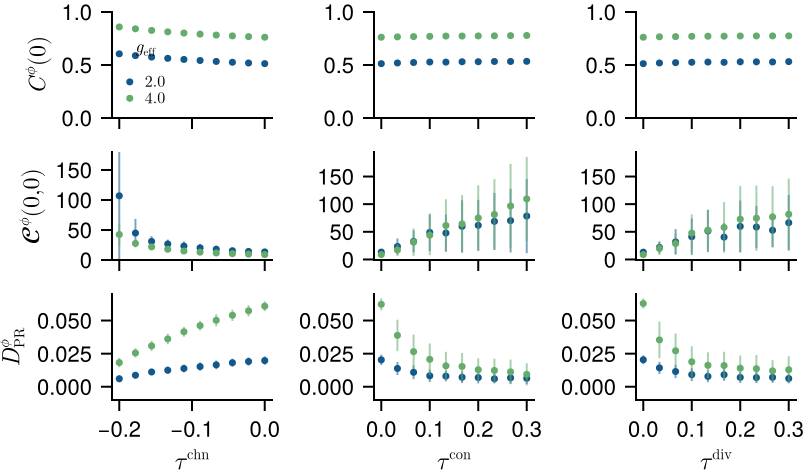

CairoMakie.Screen{IMAGE}


In [ ]:
set_theme!(DoubleColumnTheme)
errorbar_width = 1.0
f2 = Figure(size=(72*3.5*1.6, 72*3.3), figure_padding=(0.1, 5.0, 2.0, 6.0))
cmap = to_colormap(:navia10)
g_colors = cmap[[3, 7]]
markersize = 5
results = [result_chn, result_con, result_div]
xlabels = [L"\tau^{\text{chn}}", L"\tau^{\text{con}}", L"\tau^{\text{div}}"]
axes_c2  = Vector{Axis}(undef, 3)
axes_c4  = Vector{Axis}(undef, 3)
axes_dpr = Vector{Axis}(undef, 3)

for (col, (res, xlabel)) in enumerate(zip(results, xlabels))

    ax_c2 = Axis(f2[1, col],
        limits=(nothing, nothing, 0.0, 1.0)
    )
    axes_c2[col] = ax_c2
    hidexdecorations!(ax_c2, ticks=false)

    if col == 1
        ax_c2.ylabel = L"C^{\phi}(0)"
    end

    tau = res.τ

    for (i, g) in enumerate(g_eff_vec)
        y_mean = res.C2_mean[i, :]
        y_std  = res.C2_std[i, :]
        errorbars!(ax_c2, tau, y_mean, y_std, y_std;
            color=(g_colors[i], 0.55), linewidth=errorbar_width)
        scatter!(ax_c2, tau, y_mean;
            color=g_colors[i],
            markersize=markersize)
    end

    ax_c4 = if col == 1
        Axis(f2[2, col],
            limits=(nothing, nothing, 0.0, 180.0),
            yticks = [0.0, 50.0, 100.0, 150.0]
        )
    else
        Axis(f2[2, col],
            limits=(nothing, nothing, -1, nothing),
        )
    end
    axes_c4[col] = ax_c4
    hidexdecorations!(ax_c4, ticks=false)

    if col == 1
        ax_c4.ylabel = L"\mathcal{C}^{\phi}(0,0)"
    end

    for (i, g) in enumerate(g_eff_vec)
        y_mean = res.C4_mean[i, :]
        y_std  = res.C4_std[i, :]
        errorbars!(ax_c4, tau, y_mean, y_std, y_std;
            color=(g_colors[i], 0.55), linewidth=errorbar_width)
        scatter!(ax_c4, tau, y_mean;
            color=g_colors[i],
            markersize=markersize)
    end

    ax_dpr = Axis(f2[3, col],
        xlabel=xlabel,
        limits = (nothing, nothing, -0.01, nothing)
    )
    axes_dpr[col] = ax_dpr

    if col == 1
        ax_dpr.ylabel = L"D^{\phi}_{\text{PR}}"
        ax_c2.xticks = [-0.2, -0.1, 0.0]
        ax_c4.xticks = [-0.2, -0.1, 0.0]
        ax_dpr.xticks = [-0.2, -0.1, 0.0]
    end
    for (i, g) in enumerate(g_eff_vec)
        y_mean = res.Dϕ_mean[i, :]
        y_std  = res.Dϕ_std[i, :]

        errorbars!(ax_dpr, tau, y_mean, y_std, y_std;
            color=(g_colors[i], 0.55), linewidth=errorbar_width)
        scatter!(ax_dpr, tau, y_mean;
            color=g_colors[i],
            markersize=markersize)
    end
end

linkyaxes!(axes_c2[[2, 3]]...)
linkyaxes!(axes_c4[[2, 3]]...)
linkyaxes!(axes_dpr[[1, 2, 3]]...)

legend_elements = [
    MarkerElement(marker=:circle, color=g_colors[i], markersize=5)
    for i in eachindex(g_eff_vec)
]
legend_labels = [L"%$(g)" for g in g_eff_vec]
Legend(f2[1, 1], legend_elements, legend_labels, L"g_{\text{eff}}";
    tellwidth=false,
    tellheight=false,
    halign=:left,
    valign=:bottom,
    patchsize=(5, 4),
    rowgap=0.2,
    titlesize=9
)

colgap!(f2.layout, 15)
rowgap!(f2.layout, 12)
# save("images/NumericalPRDAllMotifsFullRange.pdf", f2, pt_per_unit=1)
display(f2)